<a href="https://colab.research.google.com/github/najla-alhusaini/it326-telco-churn/blob/main/Reports/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Data Summarization and Preprocessing
## Telco Customer Churn Dataset

## Setup and Initial Data Loading

**` Imports and Setup`**

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


**`Load dataset`**

In [2]:
from pathlib import Path

# Works locally (repo checkout) and in Colab (falls back to the GitHub copy)
DATA_URL = "https://raw.githubusercontent.com/najla-alhusaini/it326-telco-churn/main/Dataset/"
def data_path(name):
    for folder in [Path("../Dataset"), Path("Dataset"), Path(".")]:
        if (folder / name).exists():
            return folder / name
    return DATA_URL + name

# Load the dataset
print("Loading Telco Customer Churn Dataset...")
df = pd.read_csv(data_path("Raw_dataset.csv"))
print("Dataset loaded successfully!\n")
# Create a copy for preprocessing
df_processed = df.copy()

Loading Telco Customer Churn Dataset...
Dataset loaded successfully!



**`Display basic information`**

In [3]:
# Display basic information
print("="*50)
print("BASIC DATASET INFORMATION")
print("="*50)
print(f"Dataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}\n")

print("Dataset Columns and Data Types:")
print(df.dtypes)

print("\n" + "="*50)
# Display first few rows
print("2. DATASET SNAPSHOT (First 10 rows)")
print("="*50)
display(df.head(10))

# Statistical summary for numerical features
print("="*50)
print("3. STATISTICAL SUMMARY FOR NUMERICAL FEATURES")
print("="*50)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

if numerical_cols:
    display(df[numerical_cols].describe())
else:
    print("No numerical columns found!")

BASIC DATASET INFORMATION
Dataset Shape: (7043, 21)
Number of Rows: 7043
Number of Columns: 21

Dataset Columns and Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

2. DATASET SNAPSHOT (First 10 rows)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


3. STATISTICAL SUMMARY FOR NUMERICAL FEATURES
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Interpretation of Statistical Measures

The statistical summary above helps us understand the distribution and characteristics of the numerical features:

- **Count**: Number of valid (non-missing) entries.
- **Mean**: The average value for each feature.
- **Standard Deviation (std)**: Measures how spread out the values are.
- **Min/Max**: Show the range of values.
- **25%, 50%, 75% (Quartiles)**: Indicate the distribution of the data and help identify skewness or concentration.

### Dataset Insights
- **Tenure** ranges between 0 and 72 months, meaning customers stay anywhere from their first month to 6 years.
- **MonthlyCharges** vary between about 18 and 118, showing a wide variety of service plans.
- **SeniorCitizen** has a mean around 0.16, indicating only ~16% of customers are senior citizens overall.

These statistics help us understand the data distribution and guide preprocessing and modeling decisions.

**`Missing values analysis `**

In [4]:
# Check for missing values
print("="*50)
print("MISSING VALUES ANALYSIS")
print("="*50)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_percent
})
missing_info = missing_info[missing_info['Missing Values'] > 0]

if not missing_info.empty:
    display(missing_info)

    # Plot missing values
    plt.figure(figsize=(10, 6))
    missing_info['Percentage'].plot(kind='bar')
    plt.title('Missing Values Percentage by Column')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

# Check for empty strings or special missing values
print("\nChecking for special missing values (empty strings, etc.)...")
for col in df.columns:
    if df[col].dtype == 'object':
        empty_count = (df[col] == '').sum() + (df[col] == ' ').sum() + (df[col] == 'NA').sum()
        if empty_count > 0:
            print(f"Column '{col}' has {empty_count} empty/special values")

MISSING VALUES ANALYSIS
No missing values found in the dataset!

Checking for special missing values (empty strings, etc.)...


**`Class label distribution`**

CLASS LABEL DISTRIBUTION (Churn)
Churn Distribution:
No: 5174 (73.46%)
Yes: 1869 (26.54%)


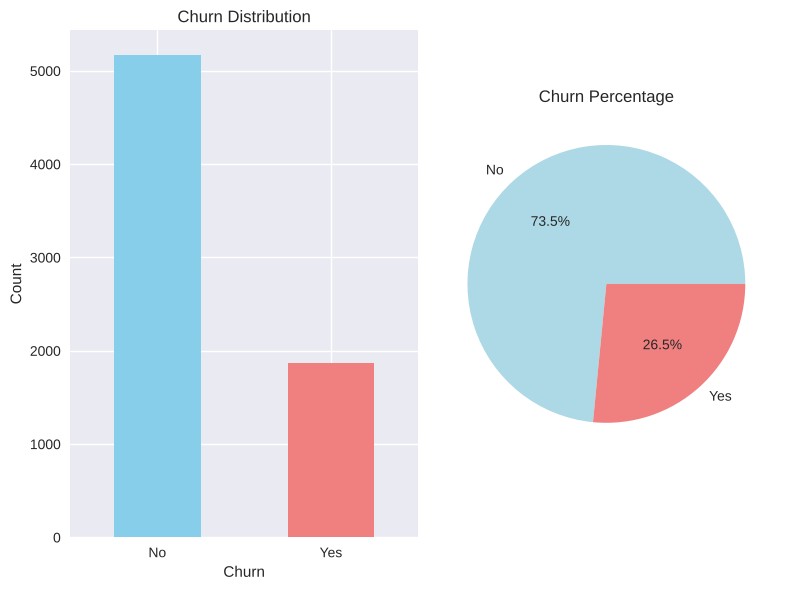

Interpretation:
- Around 26.5% of customers churned, while 73.5% stayed: the dataset is imbalanced (roughly 3:1).
- Because of this, accuracy is a misleading metric: a model that always predicts 'No churn' is already ~73.5% accurate
  while catching zero churners. Models must be judged on the churn class (recall, precision, F1, PR-AUC).
- The imbalance is handled at modeling time with class weighting (Phase 3).


In [5]:
# Class label distribution
print("="*50)
print("CLASS LABEL DISTRIBUTION (Churn)")
print("="*50)
churn_distribution = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
for label in churn_distribution.index:
    print(f"{label}: {churn_distribution[label]} ({churn_percentage[label]:.2f}%)")

# Plot class distribution
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
churn_distribution.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.pie(churn_distribution.values, labels=churn_distribution.index,
        autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Churn Percentage')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Around 26.5% of customers churned, while 73.5% stayed: the dataset is imbalanced (roughly 3:1).")
print("- Because of this, accuracy is a misleading metric: a model that always predicts 'No churn' is already ~73.5% accurate")
print("  while catching zero churners. Models must be judged on the churn class (recall, precision, F1, PR-AUC).")
print("- The imbalance is handled at modeling time with class weighting (Phase 3).")

## Data Visualization  

**`Plot 1: Histograms for numerical features`**

Plot 1: Histograms of Numerical Features


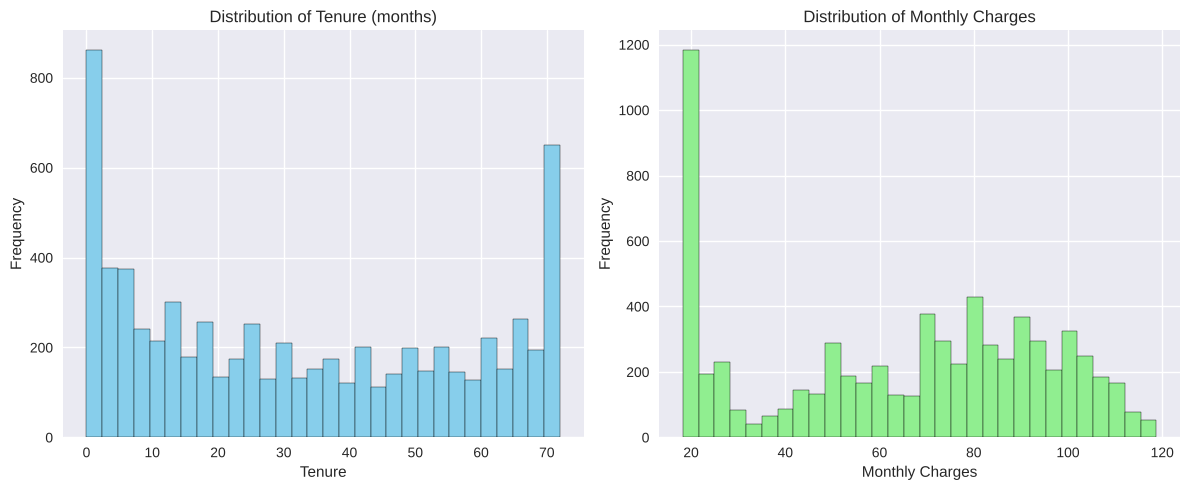

Interpretation:
- Tenure is U-shaped: many brand-new customers (21% have 6 months or less) and many long-standing ones (~15% at 66+ months).
- MonthlyCharges has a large spike around $20 (customers without internet service), while about half pay $70 or more.
- Tenure (months) and charges (dollars) are on very different scales, so scaling is applied before distance-based methods (K-Means).


In [6]:
# Plot 1: Histograms for numerical features
print("Plot 1: Histograms of Numerical Features")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tenure distribution
df['tenure'].hist(bins=30, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Tenure (months)')
axes[0].set_xlabel('Tenure')
axes[0].set_ylabel('Frequency')

# Monthly Charges distribution
df['MonthlyCharges'].hist(bins=30, ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Monthly Charges')
axes[1].set_xlabel('Monthly Charges')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Tenure is U-shaped: many brand-new customers (21% have 6 months or less) and many long-standing ones (~15% at 66+ months).")
print("- MonthlyCharges has a large spike around $20 (customers without internet service), while about half pay $70 or more.")
print("- Tenure (months) and charges (dollars) are on very different scales, so scaling is applied before distance-based methods (K-Means).")

**`Plot 2: Boxplots for numerical features `**


Plot 2: Boxplots for Numerical Features (Outlier Detection)


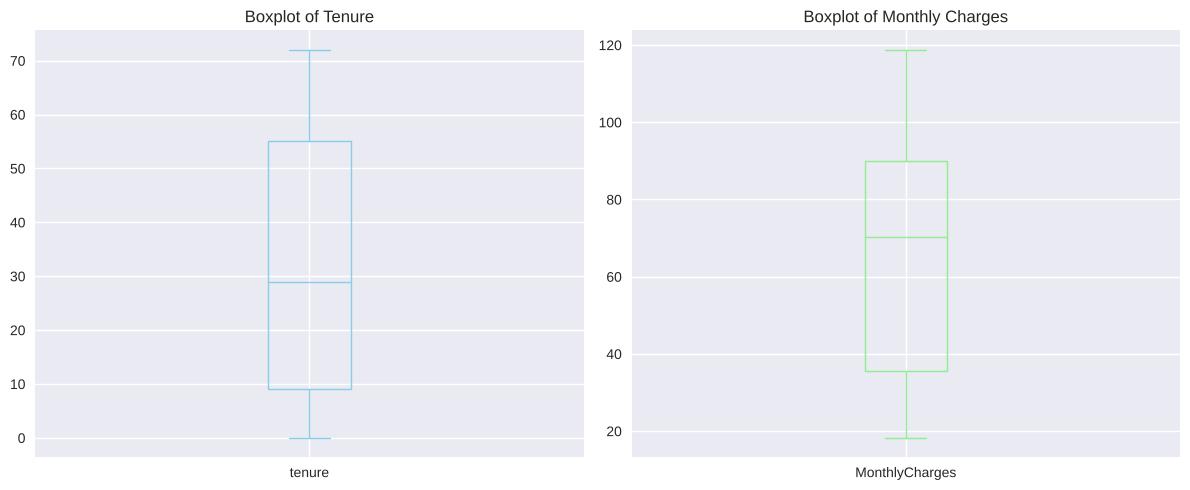

Interpretation:
- The boxplots show the data spread and central tendency for Tenure and MonthlyCharges.
- No points fall outside the whiskers, so no outlier removal is needed.
- However, since the ranges differ, scaling is still needed for distance-based algorithms.


In [7]:
# Plot 2: Boxplots for numerical features (outlier detection)
print("\nPlot 2: Boxplots for Numerical Features (Outlier Detection)")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='tenure', ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Tenure')

df.boxplot(column='MonthlyCharges', ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Monthly Charges')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- The boxplots show the data spread and central tendency for Tenure and MonthlyCharges.")
print("- No points fall outside the whiskers, so no outlier removal is needed.")
print("- However, since the ranges differ, scaling is still needed for distance-based algorithms.")

**`Plot 3: Bar plot for categorical features`**


Plot 3: Bar Plot for Contract Type


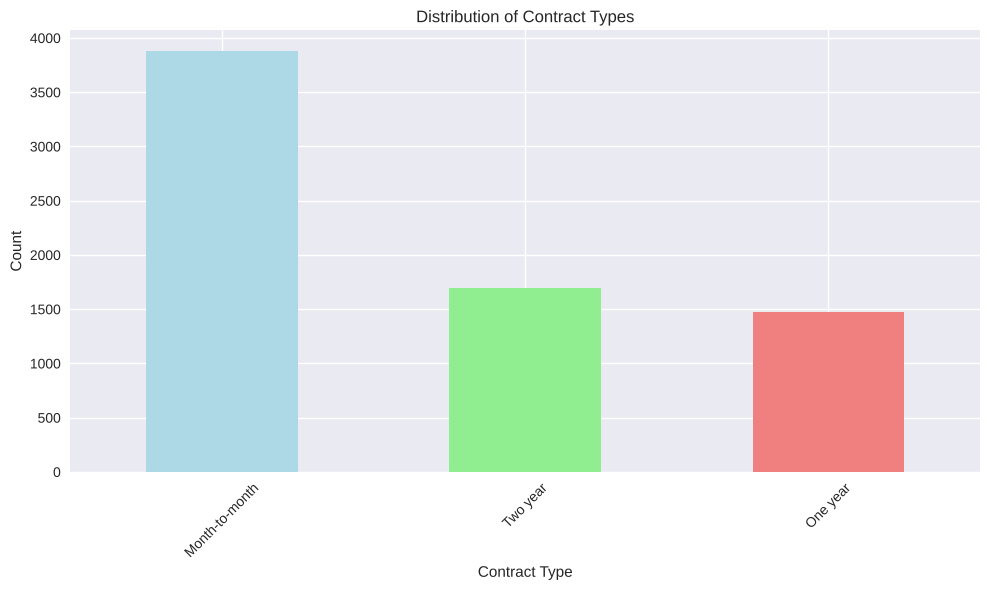

Churn rate by contract type:
  Month-to-month: 42.7%
  One year: 11.3%
  Two year: 2.8%
Interpretation:
- 55% of customers are on Month-to-month contracts; One-year and Two-year contracts are less common.
- Month-to-month customers churn far more often (~43%) than One-year (~11%) or Two-year (~3%) customers,
  so contract type is expected to be one of the strongest predictors.


In [8]:
# Plot 3: Bar plot for categorical features
print("\nPlot 3: Bar Plot for Contract Type")
plt.figure(figsize=(10, 6))
contract_dist = df['Contract'].value_counts()
contract_dist.plot(kind='bar', color=['lightblue', 'lightgreen', 'lightcoral'])
plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

churn_by_contract = (df['Churn'] == 'Yes').groupby(df['Contract']).mean() * 100
print("Churn rate by contract type:")
for contract, rate in churn_by_contract.items():
    print(f"  {contract}: {rate:.1f}%")

print("Interpretation:")
print("- 55% of customers are on Month-to-month contracts; One-year and Two-year contracts are less common.")
print("- Month-to-month customers churn far more often (~43%) than One-year (~11%) or Two-year (~3%) customers,")
print("  so contract type is expected to be one of the strongest predictors.")

**`Plot 4: Scatter plot`**


Plot 4: Scatter Plot - Tenure vs Monthly Charges colored by Churn


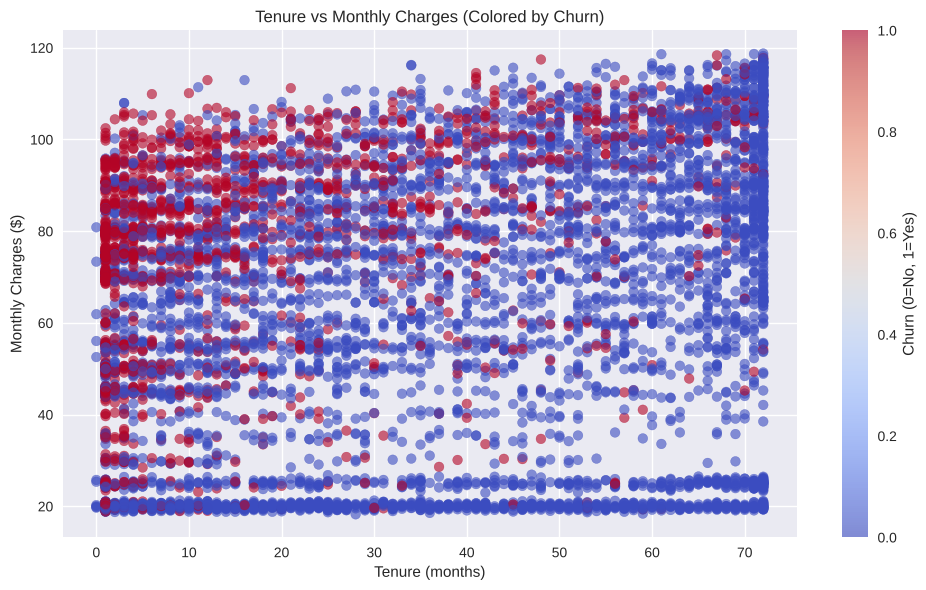

Interpretation:
- Customers with shorter tenures and higher monthly charges tend to churn more frequently.
- The plot shows a visible relationship between tenure, charges, and churn, suggesting these are key predictive features.


In [9]:
# Plot 4: Scatter plot
print("\nPlot 4: Scatter Plot - Tenure vs Monthly Charges colored by Churn")
plt.figure(figsize=(10, 6))

# Convert Churn to numeric for coloring
churn_numeric = df['Churn'].map({'Yes': 1, 'No': 0})

scatter = plt.scatter(df['tenure'], df['MonthlyCharges'],
                      c=churn_numeric, cmap='coolwarm', alpha=0.6)
plt.colorbar(scatter, label='Churn (0=No, 1=Yes)')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Tenure vs Monthly Charges (Colored by Churn)')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Customers with shorter tenures and higher monthly charges tend to churn more frequently.")
print("- The plot shows a visible relationship between tenure, charges, and churn, suggesting these are key predictive features.")

**`Five-number summary for numerical features`**

In [10]:
# Five-number summary for numerical features
print("="*50)
print("FIVE-NUMBER SUMMARY FOR NUMERICAL FEATURES")
print("="*50)

all_numeric = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
df_processed[all_numeric] = df_processed[all_numeric].apply(pd.to_numeric, errors='coerce')
five_num_summary = df_processed[all_numeric].describe().loc[['min','25%','50%','75%','max']]
display(five_num_summary)

print("\nOutlier Detection (IQR) on continuous columns (raw data):")
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[continuous_cols] = df[continuous_cols].apply(pd.to_numeric, errors='coerce')
for col in continuous_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    print(f"{col}: {len(outliers)} outliers")



FIVE-NUMBER SUMMARY FOR NUMERICAL FEATURES


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
min,0.0,0.0,18.25,18.8000
25%,0.0,9.0,35.50,401.4500
50%,0.0,29.0,70.35,1397.4750
75%,0.0,55.0,89.85,3794.7375
max,1.0,72.0,118.75,8684.8000



Outlier Detection (IQR) on continuous columns (raw data):
tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


## DATA PREPROCESSING

**`Handle TotalCharges column (convert to numeric, handle errors)`**

In [11]:
# Preprocessing Step 1: Handle TotalCharges column (convert to numeric, handle errors)
print("\nPreprocessing Step 1: Handling TotalCharges Column")
if 'TotalCharges' in df_processed.columns:
    print("Converting TotalCharges to numeric...")
    # Convert to numeric, errors will become NaN
    df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')

    # Check for newly created NaN values
    new_nans = df_processed['TotalCharges'].isnull().sum()
    print(f"Created {new_nans} NaN values during conversion")

    # Fill NaN values with 0 (assuming new customers with no charges)
    df_processed['TotalCharges'] = df_processed['TotalCharges'].fillna(0)
    print("NaN values filled with 0")

    print("Justification: TotalCharges contained non-numeric values that needed conversion.")
    print("Improvement: Now we can use this column for numerical analysis.")


Preprocessing Step 1: Handling TotalCharges Column
Converting TotalCharges to numeric...
Created 11 NaN values during conversion
NaN values filled with 0
Justification: TotalCharges contained non-numeric values that needed conversion.
Improvement: Now we can use this column for numerical analysis.


**`Handle categorical variables (Encoding)`**

In [12]:
from sklearn.preprocessing import LabelEncoder
# Preprocessing Step 2: Handle categorical variables (Encoding)
print("\nPreprocessing Step 2: Encoding Categorical Variables")
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
# Remove customerID and Churn (target variable) from encoding list
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

print(f"Categorical columns to encode: {categorical_cols}")

# Apply label encoding to categorical variables
label_encoders = {}
for col in categorical_cols:
    if col in df_processed.columns:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded column: {col}")

print("Justification: Machine learning algorithms require numerical input.")
print("Improvement: All features are now numerical and ready for modeling.")


Preprocessing Step 2: Encoding Categorical Variables
Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encoded column: gender
Encoded column: Partner
Encoded column: Dependents
Encoded column: PhoneService
Encoded column: MultipleLines
Encoded column: InternetService
Encoded column: OnlineSecurity
Encoded column: OnlineBackup
Encoded column: DeviceProtection
Encoded column: TechSupport
Encoded column: StreamingTV
Encoded column: StreamingMovies
Encoded column: Contract
Encoded column: PaperlessBilling
Encoded column: PaymentMethod
Justification: Machine learning algorithms require numerical input.
Improvement: All features are now numerical and ready for modeling.


**`Normalize numerical features`**

In [13]:
from sklearn.preprocessing import StandardScaler

# Preprocessing Step 3: Normalize ONLY true numerical features
print("\nPreprocessing Step 3: Normalizing Numerical Features")

# Only real numerical columns (not encoded categorical variables)
numerical_cols_processed = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(f"Numerical columns to normalize: {numerical_cols_processed}")

scaler = StandardScaler()
df_processed[numerical_cols_processed] = scaler.fit_transform(df_processed[numerical_cols_processed])

print("Applied StandardScaler to true numerical features only.")
print("Justification: Encoded categorical features were NOT scaled to preserve their meaning.")



Preprocessing Step 3: Normalizing Numerical Features
Numerical columns to normalize: ['tenure', 'MonthlyCharges', 'TotalCharges']
Applied StandardScaler to true numerical features only.
Justification: Encoded categorical features were NOT scaled to preserve their meaning.


**`Encode target variable`**

In [14]:
# Preprocessing Step 4: Encode target variable
print("\nPreprocessing Step 4: Encoding Target Variable (Churn)")
if 'Churn' in df_processed.columns:
    df_processed['Churn'] = df_processed['Churn'].map({'Yes': 1, 'No': 0})
    print("Encoded Churn: Yes=1, No=0")

    print("Justification: Target variable needs to be numerical for classification.")
    print("Improvement: Ready for use as target variable in ML models.")


Preprocessing Step 4: Encoding Target Variable (Churn)
Encoded Churn: Yes=1, No=0
Justification: Target variable needs to be numerical for classification.
Improvement: Ready for use as target variable in ML models.


**`Feature selection (remove customerID)`**

In [15]:
# Preprocessing Step 5: Feature selection (remove customerID)
print("\nPreprocessing Step 5: Feature Selection - Removing customerID")
if 'customerID' in df_processed.columns:
    df_processed.drop('customerID', axis=1, inplace=True)
    print("Removed customerID column")
    print("Justification: customerID is an identifier, not a predictive feature.")
    print("Improvement: Reduces dimensionality and prevents overfitting.")


Preprocessing Step 5: Feature Selection - Removing customerID
Removed customerID column
Justification: customerID is an identifier, not a predictive feature.
Improvement: Reduces dimensionality and prevents overfitting.


**`Display preprocessing results`**

In [16]:
# Display preprocessing results
print("\n9. PREPROCESSING RESULTS")
print("="*50)
print("Processed dataset shape:", df_processed.shape)
print("\nProcessed dataset info:")
print(df_processed.info())
print("\nFirst 5 rows of processed dataset:")
display(df_processed.head())
print("\nStatistical summary of processed dataset:")
display(df_processed.describe())


9. PREPROCESSING RESULTS
Processed dataset shape: (7043, 20)

Processed dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBill

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,-0.992611,0
1,1,0,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,-0.172165,0
2,1,0,0,0,-1.236724,1,0,0,2,2,0,0,0,0,0,1,3,-0.362660,-0.958066,1
3,1,0,0,0,0.514251,0,1,0,2,0,2,2,0,0,1,0,0,-0.746535,-0.193672,0
4,0,0,0,0,-1.236724,1,0,1,0,0,0,0,0,0,0,1,2,0.197365,-0.938874,1



Statistical summary of processed dataset:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7.043000e+03,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7.043000e+03,7.043000e+03,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,-2.421273e-17,0.903166,0.940508,0.872923,0.790004,0.906432,0.904444,0.797104,0.985376,0.992475,0.690473,0.592219,1.574329,-6.406285e-17,-3.783239e-17,0.265370
std,0.500013,0.368612,0.499748,0.458110,1.000071e+00,0.295752,0.948554,0.737796,0.859848,0.880162,0.879949,0.861551,0.885002,0.885091,0.833755,0.491457,1.068104,1.000071e+00,1.000071e+00,0.441561
min,0.000000,0.000000,0.000000,0.000000,-1.318165e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.545860e+00,-1.005780e+00,0.000000
25%,0.000000,0.000000,0.000000,0.000000,-9.516817e-01,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-9.725399e-01,-8.299464e-01,0.000000
50%,1.000000,0.000000,0.000000,0.000000,-1.372744e-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,1.857327e-01,-3.905282e-01,0.000000
75%,1.000000,0.000000,1.000000,1.000000,9.214551e-01,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,8.338335e-01,6.648034e-01,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.613701e+00,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,1.794352e+00,2.825806e+00,1.000000


**`Save the preprocessed dataset`**

In [17]:
# Save the preprocessed dataset next to the raw data
print("="*50)
print("\nSAVING PREPROCESSED DATASET")
print("="*50)
out_dir = Path("../Dataset") if Path("../Dataset").exists() else Path(".")
df_processed.to_csv(out_dir / "Preprocessed_dataset.csv", index=False)
print(f"Preprocessed dataset saved as '{out_dir / 'Preprocessed_dataset.csv'}'")
print("\n" + "="*50)
print("PHASE 2 COMPLETED SUCCESSFULLY!")
print("="*50)


SAVING PREPROCESSED DATASET
Preprocessed dataset saved as '../Dataset/Preprocessed_dataset.csv'

PHASE 2 COMPLETED SUCCESSFULLY!


# Data Preprocessing Justification and Results Analysis

**1. TotalCharges Conversion & Missing Value Handling**

The TotalCharges column contained non-numeric values (empty strings) that couldn't be used for numerical analysis

**method:**

Converted to numeric using pd.to_numeric(errors='coerce')

Filled resulting NaN values with 0 (new customers with no charges)

Attributes: TotalCharges

Improvement: Enabled numerical operations and analysis on this important financial feature


**2. Categorical Variable Encoding**

Why Applied: Machine learning algorithms require numerical input; categorical text data cannot be processed directly

**Method:**

Label Encoding (`LabelEncoder`) applied to every categorical column, binary and multi-category alike (e.g. gender, Partner, Contract, PaymentMethod). This suits Decision Trees, which split on thresholds and do not assume a distance between codes. For K-Means (Phase 3), the multi-category columns are one-hot encoded separately, because distance-based methods would otherwise treat the codes as ordered numbers.

Attributes: All categorical columns except customerID and Churn

Improvement: Transformed categorical data into a compact numerical format suitable for tree-based models

**3. Feature Scaling/Normalization**
Why Applied: Features had different scales and units (tenure: months, charges: dollars), which could bias distance-based algorithms

**Method:**

StandardScaler applied to true numerical features

Encoded categorical features were NOT scaled to preserve their meaning

Attributes: tenure, MonthlyCharges, TotalCharges

Improvement: Ensured all numerical features contribute equally to distance-based algorithms such as K-Means. (Decision Trees are unaffected by scaling, so fitting the scaler on the full dataset does not leak information into the classification results.)


**4. Target Variable Encoding**

Why Applied: Classification algorithms require numerical target variables

**Method:**

Simple binary mapping (Yes→1, No→0)

Attributes: Churn

Improvement: Prepared target variable for binary classification tasks


**5. Feature Selection**
Why Applied: customerID is a unique identifier, not a predictive feature; including it would let the model memorise IDs

**Method:**

Complete removal from the dataset

Attributes: customerID

Improvement: Reduced dimensionality; prevented model from learning spurious correlations with customer IDs